# 📊 SPK Rekomendasi Sekolah — K-Means + Genetic Algorithm

**Kromosom GA (5 gen):**
```
[ K | w_mhs | w_ipk_mean | w_ipk_std | w_juara_tingkat ]
```
- **K** — jumlah cluster (integer, 2–8)
- **4 bobot** — dinormalisasi otomatis → jumlah = 1.0
- **Fitness** — Davies-Bouldin Index (minimasi)

**⚠️ Arsitektur: Prestasi sebagai PENUNJANG, bukan fitur clustering**
- **Fitur clustering (3 fitur):** `mahasiswa`, `ipk_mean`, `ipk_std`
- **Penunjang ranking cluster:** `skor_prestasi_gabungan` (juara × tingkat)
- Prestasi hanya dipakai untuk *memilih label* cluster setelah K-Means selesai
- Label A/B/C ditentukan **dinamis per prodi** berdasarkan komposisi cluster

**Label Dinamis:**
- Setelah clustering selesai, cluster diranking oleh skor gabungan (IPK + prestasi)
- Cluster dengan skor tertinggi di prodi itu → Label **A** (Unggulan)
- Tidak harus konsisten antar prodi (cluster 0 di prodi X bisa = A, di prodi Y bisa = B)

| Cell | Fungsi |
|------|--------|
| 1 | Install & import library |
| 2 | Upload file Excel |
| 2b | Parser prestasi teks bebas |
| 3 | Preprocessing + rekayasa fitur prestasi |
| 4 | GA + K-Means per prodi (prestasi = penunjang) |
| 4b | Visualisasi konvergensi GA |
| 5 | Dashboard semua prodi |
| 6 | Rekomendasi sekolah per prodi |
| 7 | Download hasil ke Excel |

## 📦 Cell 1 — Install & Import Library

In [ ]:
!pip install openpyxl ipywidgets --quiet

import os, pickle, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score

warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)

# ── Nama kolom dataset ───────────────────────────────────────────
COL_SEKOLAH = 'SEKOLAH'
COL_KOTA    = 'KOTA_SEKOLAH'
COL_PROV    = 'PROP_SEKOLAH'
COL_IPK     = 'IPK'
COL_PRODI   = 'PROGRAM_STUDI'
COL_JURUSAN = 'JURUSAN'           # jurusan mahasiswa di Polinema
COL_JURSK   = 'JURUSAN_SEKOLAH'   # jurusan di sekolah asal
COL_STATUS  = 'STATUS'
COL_NPSN    = 'NPSN'
COL_P1      = 'PRESTASI_1'        # peringkat juara: 1/2/3
COL_P2      = 'PRESTASI_2'        # tingkat: 1=sekolah .. 5=internasional

KOLOM_WAJIB = [COL_SEKOLAH, COL_KOTA, COL_PROV, COL_IPK, COL_PRODI]

# ── Aturan klasifikasi akademik ──────────────────────────────────
# Kata kunci pada COL_JURUSAN (jurusan mahasiswa di Polinema)
# Jika mengandung salah satu kata ini → prestasi = AKADEMIK
AKADEMIK_KEYWORDS = [
    'TEKNIK', 'MIPA', 'IPA', 'IPS', 'BAHASA',
    'SAINS', 'MATEMATIKA', 'FISIKA', 'KIMIA', 'BIOLOGI'
]
# Semua jurusan SMA (mengandung 'SMA' di COL_JURSK) → AKADEMIK
# SMK yang tidak mengandung keyword di atas → NON-AKADEMIK

LABEL_COLOR = {'A': '#27ae60', 'B': '#2980b9', 'C': '#c0392b'}
LABEL_DESC  = {'A': 'Unggulan', 'B': 'Menengah', 'C': 'Perlu Perhatian'}

STATE = {
    'df_raw'         : None,
    'df_clean'       : None,
    'hasil_per_prodi': {},
    'df_result_all'  : None,
    'ga_log'         : {},
}

print('✅ Library berhasil diimport.')
print(f'   Kolom wajib       : {KOLOM_WAJIB}')
print(f'   Keyword akademik  : {AKADEMIK_KEYWORDS}')
print('   ➡️  Lanjut ke Cell 2.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.1 MB/s eta 0:00:00
✅ Library berhasil diimport.
   Kolom wajib       : ['SEKOLAH', 'KOTA_SEKOLAH', 'PROP_SEKOLAH', 'IPK', 'PROGRAM_STUDI']
   Keyword akademik  : ['TEKNIK', 'MIPA', 'IPA', 'IPS', 'BAHASA', 'SAINS', 'MATEMATIKA', 'FISIKA', 'KIMIA', 'BIOLOGI']
   ➡️  Lanjut ke Cell 2.


## 📂 Cell 2 — Upload File Excel

In [ ]:
print('📂 Pilih file Excel (.xlsx) ...')
print(f'   Kolom WAJIB   : {KOLOM_WAJIB}')
print('   Kolom prestasi: PRESTASI_1 (juara: 1/2/3), PRESTASI_2 (tingkat: 1-5)')
print()

uploaded = files.upload()

if not uploaded:
    print('❌ Tidak ada file yang diupload.')
else:
    all_dfs = []
    for fname in uploaded:
        if not fname.endswith('.xlsx'):
            print(f'⚠️  {fname} bukan .xlsx, dilewati.')
            continue
        try:
            df = pd.read_excel(fname)
            df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')
            missing = [c for c in KOLOM_WAJIB if c not in df.columns]
            if missing:
                print(f'❌ {fname} tidak punya kolom wajib: {missing}')
                print(f'   Kolom yang ada: {list(df.columns)}')
                continue
            all_dfs.append(df)
            print(f'✅ {fname} — {df.shape[0]:,} baris | kolom: {list(df.columns)}')
        except Exception as e:
            print(f'❌ Gagal membaca {fname}: {e}')

    if all_dfs:
        df_raw = pd.concat(all_dfs, ignore_index=True, sort=False)
        STATE['df_raw'] = df_raw
        print(f'\n📊 Total baris: {df_raw.shape[0]:,}')
        display(df_raw.head(3))
        print('\n✅ Upload selesai. ➡️  Lanjut ke Cell 3.')
    else:
        print('❌ Tidak ada file valid.')

📂 Pilih file Excel (.xlsx) ...
   Kolom WAJIB   : ['SEKOLAH', 'KOTA_SEKOLAH', 'PROP_SEKOLAH', 'IPK', 'PROGRAM_STUDI']
   Kolom prestasi: PRESTASI_1 (juara: 1/2/3), PRESTASI_2 (tingkat: 1-5)



Saving Dataset Mhs Polinema1.xlsx to Dataset Mhs Polinema1.xlsx
✅ Dataset Mhs Polinema1.xlsx — 14,224 baris | kolom: ['NPSN', 'SEKOLAH', 'KOTA_SEKOLAH', 'PROP_SEKOLAH', 'JURUSAN_SEKOLAH', 'PROGRAM_STUDI', 'JURUSAN', 'STATUS', 'IPK', 'PRESTASI_1', 'PRESTASI_2']

📊 Total baris: 14,224


,NPSN,SEKOLAH,KOTA_SEKOLAH,PROP_SEKOLAH,JURUSAN_SEKOLAH,PROGRAM_STUDI,JURUSAN,STATUS,IPK,PRESTASI_1,PRESTASI_2
0,20517732,SMAN 1 PAGAK,Kab. Malang,Prop. Jawa Timur,MIPA,Teknik Mesin,TEKNIK MESIN,Aktif,3.01,NaN,NaN
1,20514344,SMAN 01 TALUN,Kab. Blitar,Prop. Jawa Timur,IPA,Teknik Mesin,TEKNIK MESIN,Aktif,3.61,NaN,NaN
2,20584775,MAS MANBAIL FUTUH,Kab. Tuban,Prop. Jawa Timur,IPA,Teknik Mesin,TEKNIK MESIN,Aktif,2.93,NaN,NaN



✅ Upload selesai. ➡️  Lanjut ke Cell 3.


## 🔧 Cell 2b — Parser Prestasi Teks Bebas → PRESTASI_1 & PRESTASI_2

**Jalankan cell ini SEBELUM Cell 3 jika kolom prestasi Anda berisi teks bebas**
(contoh: `JUARA 1 LOMBA TARTIL AL-QUR'AN TINGKAT SEKOLAH`)

Cell ini secara otomatis mengekstrak:
- `PRESTASI_1` — peringkat juara: 1=Juara1, 2=Juara2, 3=Juara3
- `PRESTASI_2` — tingkat kompetisi: 1=Sekolah, 2=Kab/Kota, 3=Provinsi, 4=Nasional, 5=Internasional


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 🔧 Cell 2b — Parser Prestasi Teks Bebas → PRESTASI_1 & PRESTASI_2
# Kolom PRESTASI_1 di Excel berisi teks → cell ini mengekstrak angka.
# Jalankan SETELAH Cell 2 (upload) dan SEBELUM Cell 3 (preprocessing)
# ══════════════════════════════════════════════════════════════════════
import re

def parse_prestasi_teks(teks):
    """Ekstrak (PRESTASI_1, PRESTASI_2) dari teks prestasi bebas.
    PRESTASI_1: 1=Juara1, 2=Juara2, 3=Juara3, 0=tidak ada
    PRESTASI_2: 1=Sekolah, 2=Kab/Kota, 3=Provinsi, 4=Nasional, 5=Internasional
    """
    if pd.isna(teks) or str(teks).strip() in ['', '0', 'NAN', 'NONE', '-', '- - TINGKAT -']:
        return 0, 0
    t = str(teks).upper().strip()

    # PARTISIPAN/PESERTA → tidak ada prestasi
    if re.search(r'\bPARTISIPAN\b|\bPESERTA\b', t):
        return 0, 0

    # ── Deteksi tingkat: cari semua frase 'TINGKAT X', ambil tertinggi ──
    pola_tingkat_map = [
        (r'TINGKAT\s+(INTERNASIONAL|INTERNATIONAL)', 5),
        (r'TINGKAT\s+NASIONAL', 4),
        (r'TINGKAT\s+(PROVINSI|PROPINSI|KERASIDENAN|KARESIDENAN|KORWIL|REGIONAL)', 3),
        (r'TINGKAT\s+(KABUPATEN\s*[/&]?\s*KOTA|KABUPATEN|KOTA\s*[/]\s*KAB|KAB\.?\s*KOTA|KOTA\s+KABUPATEN)', 2),
        (r'TINGKAT\s+KOTA\b', 2),
        (r'TINGKAT\s+KAB\.?\b', 2),
        (r'TINGKAT\s+(SEKOLAH|SMA|SMK)', 1),
    ]
    tingkat_candidates = [v for pola, v in pola_tingkat_map if re.search(pola, t)]
    # Tambah dari konteks: 'SE KABUPATEN/SE KOTA' = level kab/kota
    if re.search(r'SE[\s-]?KABUPATEN|SE[\s-]?KOTA\b', t):
        tingkat_candidates.append(2)
    tingkat = max(tingkat_candidates) if tingkat_candidates else 0

    # Fallback kontekstual jika tidak ada frase 'TINGKAT X'
    if tingkat == 0:
        if re.search(r'INTERNASIONAL|INTERNATIONAL|ASEAN|\bASIA\b|WORLD|GLOBAL|DUNIA', t): tingkat = 5
        elif re.search(r'\bNASIONAL\b|NATIONAL|\bINDONESIA\b|PERGURUAN\s+TINGGI|NUSANTARA', t): tingkat = 4
        elif re.search(r'KERASIDENAN|KARESIDENAN|KORWIL', t): tingkat = 3
        elif re.search(r'REGIONAL\b', t): tingkat = 3
        elif re.search(r'SE[\s-]?KABUPATEN|SE[\s-]?KOTA\b|\bKABUPATEN\b|\bKOTAMADYA\b', t): tingkat = 2
        elif re.search(r'\bKAB\.?\b', t): tingkat = 2
        elif re.search(r'\bSEKOLAH\b|\bSMA\b|\bSMK\b', t): tingkat = 1

    # ── Deteksi peringkat juara ──────────────────────────────────────
    juara = 0
    pola_juara = [
        (r'JUARA\s*(KE)?[-–\s]?1(?![0-9])',        1),
        (r'JUARA\s*(KE)?[-–\s]?I(?!I|[A-Z])',      1),
        (r'JUARA\s+(SATU|PERTAMA)\b',              1),
        (r'JUARA\s*(KE)?[-–\s]?2(?![0-9])',        2),
        (r'JUARA\s*(KE)?[-–\s]?II(?!I)',           2),
        (r'JUARA\s+(DUA|KEDUA)\b',                2),
        (r'JUARA\s*(KE)?[-–\s]?3(?![0-9])',        3),
        (r'JUARA\s*(KE)?[-–\s]?III\b',            3),
        (r'JUARA\s+(TIGA|KETIGA)\b',              3),
        (r'JUARA\s*(KE)?[-–\s]?[456789]\b',       -1),  # juara 4+ = tidak dihitung
        (r'JUARA\s+HARAPAN',                      3),
        (r'JUARA\s+UMUM',                         1),
        (r'3RD\s+RUNNER\s*UP',                    3),
        (r'2ND\s+RUNNER\s*UP',                    3),
        (r'1ST\s+RUNNER\s*UP',                    2),
        (r'\bRUNNER\s*UP\b',                      2),
        (r'PEMENANG\s+(1|I|SATU|PERTAMA)\b',      1),
        (r'PEMENANG\s+(2|II|DUA|KEDUA)\b',        2),
        (r'PEMENANG\s+(3|III|TIGA|KETIGA)\b',     3),
        (r'MEDALI\s+(EMAS|GOLD)',                 1),
        (r'MEDALI\s+(PERAK|SILVER)',              2),
        (r'MEDALI\s+(PERUNGGU|BRONZE)',           3),
        (r'BEST\s+(PAPER|POSTER|SPEAKER|TEAM|STUDENT|STRATEGY)', 1),
        (r'\bFINALIS\b',                          3),
        (r'\bMULA\s+3\b',                         3),
    ]
    for pola, rank in pola_juara:
        if re.search(pola, t):
            juara = rank
            break

    if juara == -1:   # juara 4+ → tidak dihitung
        return 0, 0

    # Fallback: ada kata JUARA tapi tidak cocok pola
    if juara == 0 and 'JUARA' in t:
        m = re.search(r'JUARA\s*(\d+)', t)
        if m:
            n = int(m.group(1))
            juara = n if n in (1, 2, 3) else 0
        else:
            juara = 1

    # Fallback: angka di awal teks (contoh: '3 FUTSAL TINGKAT SEKOLAH')
    if juara == 0:
        m = re.match(r'^(\d)\s+\w', t)
        if m and int(m.group(1)) in (1, 2, 3):
            juara = int(m.group(1))

    if juara == 0:
        return 0, 0   # tidak ada juara → tingkat tidak relevan

    return juara, (tingkat if tingkat > 0 else 1)


# ════════════════════════════════════════════════════════════════════
if STATE['df_raw'] is None:
    print('❌ Jalankan Cell 2 (upload) terlebih dahulu.')
else:
    df_tmp = STATE['df_raw'].copy()

    # Kolom PRESTASI_1 di Excel berisi teks; PRESTASI_2 kosong.
    COL_TEKS = 'PRESTASI_1'

    if COL_TEKS not in df_tmp.columns:
        print(f'❌ Kolom "{COL_TEKS}" tidak ditemukan!')
        print(f'   Kolom yang ada: {list(df_tmp.columns)}')
    else:
        # Simpan teks asli untuk preview
        teks_asli = df_tmp[COL_TEKS].astype(str)
        mask_ada  = ~teks_asli.str.strip().isin(['', '0', 'NAN', 'NONE', '-', '- - TINGKAT -', 'NAN'])
        n_teks    = mask_ada.sum()
        print(f'📌 Baris dengan teks prestasi: {n_teks:,} dari {len(df_tmp):,} total')

        # Parse
        parsed = teks_asli.apply(parse_prestasi_teks)
        df_tmp['PRESTASI_1'] = [p[0] for p in parsed]   # timpa teks dengan angka
        df_tmp['PRESTASI_2'] = [p[1] for p in parsed]   # isi kolom yang kosong

        n_ada  = (df_tmp['PRESTASI_1'] > 0).sum()
        n_miss = n_teks - n_ada

        print(f'\n✅ Hasil parsing:')
        print(f'   Berhasil diparsing    : {n_ada:,} ({n_ada/len(df_tmp)*100:.1f}%)')
        print(f'   Teks ada tapi miss    : {n_miss:,}  (kemungkinan Juara 4+, Partisipan, atau format baru)')
        print(f'   Distribusi PRESTASI_1 : {dict(sorted(df_tmp["PRESTASI_1"].value_counts().items()))}')
        print(f'   Distribusi PRESTASI_2 : {dict(sorted(df_tmp["PRESTASI_2"].value_counts().items()))}')

        # Preview berhasil
        _preview_df = pd.DataFrame({'TEKS_ASLI': teks_asli, 'P1': df_tmp['PRESTASI_1'], 'P2': df_tmp['PRESTASI_2']})
        berhasil = _preview_df[_preview_df['P1'] > 0].head(10)
        if len(berhasil):
            print(f'\n✅ Contoh BERHASIL diparsing:')
            display(berhasil.reset_index(drop=True))

        # Preview yang gagal
        gagal = _preview_df[(df_tmp['PRESTASI_1'] == 0) & mask_ada]
        if len(gagal):
            print(f'\n⚠️  Teks yang tidak terdeteksi ({len(gagal):,} baris — sample):')
            display(gagal[['TEKS_ASLI']].drop_duplicates().head(10).reset_index(drop=True))
            print('   → Jika pola penting terlewat, tambahkan ke pola_juara atau pola_tingkat_map.')

        # Simpan ke STATE
        STATE['df_raw'] = df_tmp
        print('\n✅ STATE["df_raw"] diperbarui — PRESTASI_1 & PRESTASI_2 sekarang berisi angka.')
        print('   ➡️  Lanjut ke Cell 3 (preprocessing).')


📌 Baris dengan teks prestasi: 14,165 dari 14,224 total

✅ Hasil parsing:
   Berhasil diparsing    : 1,778 (12.5%)
   Teks ada tapi miss    : 12,387  (kemungkinan Juara 4+, Partisipan, atau format baru)
   Distribusi PRESTASI_1 : {0: 12446, 1: 700, 2: 513, 3: 565}
   Distribusi PRESTASI_2 : {0: 12446, 1: 714, 2: 459, 3: 210, 4: 367, 5: 28}

✅ Contoh BERHASIL diparsing:


,TEKS_ASLI,P1,P2
0,JUARA 2 FESTIVAL FUTSAL LINTAS JAWA TIMUR 2024...,2,1
1,JUARA 2 INDONESIA INTERNASIONAL TAEKWONDO CHAM...,2,5
2,"JUARA 1 LIGA KACABDIN ""FREE FIRE"" SE KABUPATEN...",1,2
3,JUARA 1 LOMBA TARTIL AL-QUR'AN TINGKAT SEKOLAH,1,1
4,JUARA 3 GASMI CUP TINGKAT KERASIDENAN KEDIRI,3,3
5,JUARA 2 TURNAMENT MOBILE LEGEND AL QOLAM TINGK...,2,1
6,JUARA 1 GARENA YOUTH CHAMPIONSHIP TINGKAT SEKOLAH,1,1
7,MULA 3 LKBB TINGKAT PROVINSI,3,3
8,JUARA 2 TINGKAT KOTA BASKET JUNIOR TINGKAT SEK...,2,2
9,3RD RUNNER UP ASEC SPEECH COMPETITION TINGKAT ...,3,4



⚠️  Teks yang tidak terdeteksi (12,387 baris — sample):


,TEKS_ASLI
0,nan
1,JUARA 4 FUTSAL TOURNAMENT POCARI SWEAT PIALA P...
2,PARTISIPAN NECESA 2.0 TINGKAT NASIONAL
3,14 ALBANJARI TINGKAT PROVINSI JATIM
4,SEMIFINAL ELECTRA ITS TINGKAT NASIONAL
5,PARTISIPAN PEMBINAAN MENTAL DAN FISIK TINGKAT ...
6,4 KSM TINGKAT KABUPATEN
7,GOLD MEDAL YOUTH NATIONAL SCIENCE FAIR 2024 TI...
8,WAKIL KETUA OSIS KETUA 2 OSIS SMA NEGERI 2 MAL...
9,PESERTA NATIONAL LINE FOLLOWER ROBOT CONTEST K...


   → Jika pola penting terlewat, tambahkan ke pola_juara atau pola_tingkat_map.

✅ STATE["df_raw"] diperbarui — PRESTASI_1 & PRESTASI_2 sekarang berisi angka.
   ➡️  Lanjut ke Cell 3 (preprocessing).


## 🧹 Cell 3 — Preprocessing + Rekayasa Fitur Prestasi

> ⚠️ **Pastikan Cell 2b sudah dijalankan** sebelum Cell 3 jika data prestasi Anda berupa teks bebas!

**Fitur prestasi yang dibuat per mahasiswa:**
- `skor_juara` — nilai terbalik juara: Juara1=3, Juara2=2, Juara3=1, tidak ada=0
- `skor_tingkat` — nilai tingkat: Internasional=5, Nasional=4, dst
- `is_akademik` — 1 jika jurusan mengandung keyword akademik, 0 jika tidak

**Fitur agregat per sekolah (untuk clustering):**
- `rata_juara` — rata-rata skor juara mahasiswa dari sekolah itu
- `rata_tingkat` — rata-rata skor tingkat
- `jml_prestasi_akademik` — total mahasiswa berprestasi akademik
- `jml_prestasi_nonakademik` — total mahasiswa berprestasi non-akademik


🔍 Sebelum preprocessing:
   Total baris : 14,224
   Null (wajib): {'SEKOLAH': 0, 'KOTA_SEKOLAH': 0, 'PROP_SEKOLAH': 0, 'IPK': 0, 'PROGRAM_STUDI': 0}
⚠️  3,811 baris dibuang karena IPK = 0 atau tidak valid
   IPK valid (0 < IPK ≤ 4.0): 9,834 baris tersisa

✅ Setelah preprocessing & rekayasa fitur:
   Baris tersisa         : 9,834
   Sekolah unik          : 1,593
   Program Studi         : 37 prodi

   📊 Ringkasan Prestasi:
   Mahasiswa berprestasi : 1,167 (11.9%)
   Prestasi Akademik     : 606
   Prestasi Non-Akademik : 561


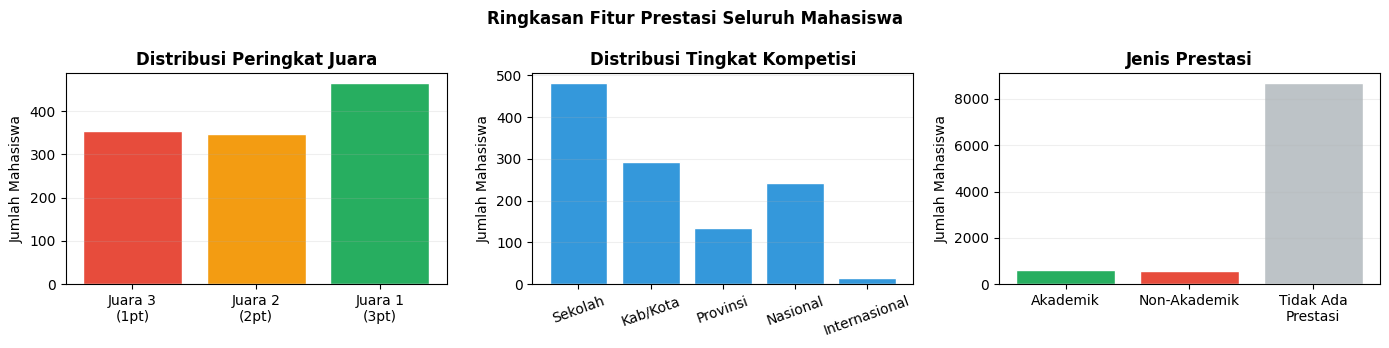


✅ Rekayasa fitur selesai. ➡️  Lanjut ke Cell 4.


In [ ]:
if STATE['df_raw'] is None:
    print('❌ Jalankan Cell 2 terlebih dahulu.')
else:
    df = STATE['df_raw'].copy()

    print('🔍 Sebelum preprocessing:')
    print(f'   Total baris : {df.shape[0]:,}')
    print(f'   Null (wajib): {df[KOLOM_WAJIB].isnull().sum().to_dict()}')

    # 1. Bersihkan data dasar
    df = df.dropna(subset=KOLOM_WAJIB).drop_duplicates().reset_index(drop=True)

    df[COL_IPK] = pd.to_numeric(
        df[COL_IPK].astype(str).str.replace(',', '.', regex=False).str.strip(),
        errors='coerce'
    )
    df = df.dropna(subset=[COL_IPK])
    n_before = df.shape[0]
    df = df[(df[COL_IPK] > 0.0) & (df[COL_IPK] <= 4.0)]  # IPK=0 dibuang
    n_removed = n_before - df.shape[0]
    if n_removed > 0:
        print(f'⚠️  {n_removed:,} baris dibuang karena IPK = 0 atau tidak valid')
    print(f'   IPK valid (0 < IPK ≤ 4.0): {df.shape[0]:,} baris tersisa')

    for col in [COL_SEKOLAH, COL_KOTA, COL_PROV, COL_PRODI]:
        df[col] = df[col].astype(str).str.strip().str.upper()
    for col in [COL_JURUSAN, COL_JURSK, COL_STATUS]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.upper()

    # 2. Konversi PRESTASI_1 (juara) dan PRESTASI_2 (tingkat)
    for col in [COL_P1, COL_P2]:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(',', '.', regex=False),
                errors='coerce'
            ).fillna(0)

    # 3. Rekayasa fitur: skor_juara
    #    PRESTASI_1: 1=Juara1, 2=Juara2, 3=Juara3, 0=tidak ada
    #    Dibalik: Juara1 → 3 poin, Juara2 → 2, Juara3 → 1, 0 → 0
    if COL_P1 in df.columns:
        juara_map = {1: 3, 2: 2, 3: 1, 0: 0}
        df['skor_juara'] = df[COL_P1].map(juara_map).fillna(0)
    else:
        df['skor_juara'] = 0
        print('⚠️  Kolom PRESTASI_1 tidak ditemukan, skor_juara = 0')

    # 4. Rekayasa fitur: skor_tingkat
    #    PRESTASI_2: 1=sekolah, 2=kab/kota, 3=provinsi, 4=nasional, 5=internasional
    if COL_P2 in df.columns:
        df['skor_tingkat'] = df[COL_P2].clip(0, 5)
    else:
        df['skor_tingkat'] = 0
        print('⚠️  Kolom PRESTASI_2 tidak ditemukan, skor_tingkat = 0')

    # 5. Rekayasa fitur: is_akademik
    #    Berdasarkan COL_JURUSAN (jurusan mahasiswa di Polinema)
    #    + semua yang dari SMA (COL_JURSK mengandung 'SMA') → Akademik
    def classify_akademik(row):
        jurusan_polinema = str(row.get(COL_JURUSAN, '')).upper()
        jursk = str(row.get(COL_JURSK, '')).upper()

        # SMA semua jurusan → akademik
        if 'SMA' in jursk or 'MA ' in jursk:
            return 1
        # SMK: cek keyword
        for kw in AKADEMIK_KEYWORDS:
            if kw in jurusan_polinema:
                return 1
        return 0

    if COL_JURUSAN in df.columns or COL_JURSK in df.columns:
        df['is_akademik'] = df.apply(classify_akademik, axis=1)
    else:
        df['is_akademik'] = 1  # default semua akademik jika kolom tidak ada
        print('⚠️  Kolom JURUSAN/JURUSAN_SEKOLAH tidak ditemukan, is_akademik = 1 (semua)')

    # 6. Tandai mahasiswa yang punya prestasi (skor_juara > 0)
    df['punya_prestasi']      = (df['skor_juara'] > 0).astype(int)
    df['prestasi_akademik']   = ((df['punya_prestasi'] == 1) & (df['is_akademik'] == 1)).astype(int)
    df['prestasi_nonakademik']= ((df['punya_prestasi'] == 1) & (df['is_akademik'] == 0)).astype(int)

    df = df.reset_index(drop=True)
    STATE['df_clean'] = df

    # ── Ringkasan ────────────────────────────────────────────────
    n_prestasi   = (df['punya_prestasi'] == 1).sum()
    n_akademik   = df['prestasi_akademik'].sum()
    n_nonakademik= df['prestasi_nonakademik'].sum()

    print(f'\n✅ Setelah preprocessing & rekayasa fitur:')
    print(f'   Baris tersisa         : {df.shape[0]:,}')
    print(f'   Sekolah unik          : {df[COL_SEKOLAH].nunique():,}')
    print(f'   Program Studi         : {df[COL_PRODI].nunique()} prodi')
    print(f'\n   📊 Ringkasan Prestasi:')
    print(f'   Mahasiswa berprestasi : {n_prestasi:,} ({n_prestasi/df.shape[0]*100:.1f}%)')
    print(f'   Prestasi Akademik     : {n_akademik:,}')
    print(f'   Prestasi Non-Akademik : {n_nonakademik:,}')

    # Distribusi skor juara & tingkat
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    juara_dist = df[df['skor_juara']>0]['skor_juara'].value_counts().sort_index()
    axes[0].bar(['Juara 3\n(1pt)','Juara 2\n(2pt)','Juara 1\n(3pt)'],
                [juara_dist.get(1,0), juara_dist.get(2,0), juara_dist.get(3,0)],
                color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white')
    axes[0].set_title('Distribusi Peringkat Juara', fontweight='bold')
    axes[0].set_ylabel('Jumlah Mahasiswa')
    axes[0].grid(True, alpha=0.2, axis='y')

    tingkat_lbl = ['Sekolah','Kab/Kota','Provinsi','Nasional','Internasional']
    tingkat_val = [df[df['skor_tingkat']==i].shape[0] for i in range(1,6)]
    axes[1].bar(tingkat_lbl, tingkat_val, color='#3498db', edgecolor='white')
    axes[1].set_title('Distribusi Tingkat Kompetisi', fontweight='bold')
    axes[1].set_ylabel('Jumlah Mahasiswa')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(True, alpha=0.2, axis='y')

    axes[2].bar(['Akademik','Non-Akademik','Tidak Ada\nPrestasi'],
                [n_akademik, n_nonakademik, df.shape[0]-n_prestasi],
                color=['#27ae60','#e74c3c','#bdc3c7'], edgecolor='white')
    axes[2].set_title('Jenis Prestasi', fontweight='bold')
    axes[2].set_ylabel('Jumlah Mahasiswa')
    axes[2].grid(True, alpha=0.2, axis='y')

    plt.suptitle('Ringkasan Fitur Prestasi Seluruh Mahasiswa', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n✅ Rekayasa fitur selesai. ➡️  Lanjut ke Cell 4.')

## 🧬 Cell 4 — GA + K-Means per Prodi (Prestasi = Penunjang)

**Arsitektur Baru:**
- Prestasi **TIDAK** masuk ke dalam fitur K-Means
- K-Means hanya memakai 3 fitur murni akademik: `mahasiswa`, `ipk_mean`, `ipk_std`
- Setelah cluster terbentuk, skor prestasi dihitung per cluster sebagai **penunjang** ranking
- Label A/B/C diberikan **dinamis per prodi** setelah clustering

**Kromosom GA (5 gen):**
```
[ K | w_mhs | w_ipk_mean | w_ipk_std | w_prestasi ]
```
1. `mahasiswa` — jumlah mahasiswa dari sekolah di prodi ini
2. `ipk_mean` — rata-rata IPK
3. `ipk_std` — standar deviasi IPK (konsistensi)
4. `skor_prestasi` — skor prestasi gabungan (hanya untuk ranking cluster, bukan clustering)

In [ ]:
if STATE['df_clean'] is None:
    print('❌ Jalankan Cell 3 terlebih dahulu.')
else:
    # ════════════════════════════════════════════════════════════
    # KONFIGURASI
    K_MIN          = 2
    K_MAX          = 8
    MIN_SEKOLAH    = 5
    RANDOM_STATE   = 42
    POP_SIZE       = 20
    N_GEN          = 30
    CROSSOVER_RATE = 0.8
    MUTATION_RATE  = 0.2
    TOURNAMENT_K   = 3
    ELITISM        = 2
    # ════════════════════════════════════════════════════════════

    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    df         = STATE['df_clean'].copy()
    prodi_list = sorted(df[COL_PRODI].unique())

    # ──────────────────────────────────────────────────────────
    # FITUR CLUSTERING: hanya 3 fitur murni (tanpa prestasi)
    # Prestasi dihitung terpisah sebagai penunjang ranking
    # ──────────────────────────────────────────────────────────
    FITUR_CLUSTER = ['mahasiswa', 'ipk_mean', 'ipk_std']   # ← fitur K-Means
    N_BOBOT       = len(FITUR_CLUSTER)   # = 3 (bobot untuk GA)

    # ── Normalisasi helper ───────────────────────────────────────
    def _norm(s):
        mn, mx = s.min(), s.max()
        return (s - mn)/(mx - mn) if mx != mn else pd.Series(0.5, index=s.index)

    # ── Agregasi per sekolah dalam satu prodi ───────────────────
    def agregasi_sekolah(df_prodi):
        df_sk = df_prodi.groupby(COL_SEKOLAH).agg(
            mahasiswa               = (COL_IPK,                'count'),
            ipk_mean                = (COL_IPK,                'mean'),
            ipk_std                 = (COL_IPK,                'std'),
            # ── Penunjang: prestasi (tidak dipakai clustering) ──
            rata_juara              = ('skor_juara',           'mean'),
            rata_tingkat            = ('skor_tingkat',         'mean'),
            jml_prestasi_akademik   = ('prestasi_akademik',    'sum'),
            jml_prestasi_nonakademik= ('prestasi_nonakademik', 'sum'),
        ).fillna(0).reset_index()

        # Skor prestasi gabungan per sekolah (penunjang, bukan fitur cluster)
        # Rumus: rata_juara × rata_tingkat (0 jika tidak punya prestasi)
        df_sk['skor_prestasi'] = df_sk['rata_juara'] * df_sk['rata_tingkat']
        return df_sk

    # ════════════════════════════════════════════════════════════
    # GENETIC ALGORITHM
    # Kromosom: [K, w_mhs, w_ipk_mean, w_ipk_std]
    # Bobot hanya untuk 3 fitur clustering (bukan prestasi)
    # ════════════════════════════════════════════════════════════

    def init_chromosome():
        k = random.randint(K_MIN, K_MAX)
        w = np.random.dirichlet(np.ones(N_BOBOT))
        return [float(k)] + list(w)

    def decode(chrom):
        k       = max(K_MIN, min(K_MAX, int(round(chrom[0]))))
        weights = np.array(chrom[1:N_BOBOT+1])
        weights = np.clip(weights, 1e-6, None)
        weights = weights / weights.sum()
        return k, weights

    def fitness_fn(chrom, df_sk, scaler):
        """Fitness: Davies-Bouldin Index pada FITUR_CLUSTER saja."""
        k, _ = decode(chrom)
        k    = min(k, df_sk.shape[0] - 1)
        if k < 2:
            return 999.0, None, None
        X_sc = scaler.transform(df_sk[FITUR_CLUSTER].values)
        try:
            km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            labels = km.fit_predict(X_sc)
            if len(np.unique(labels)) < 2:
                return 999.0, None, None
            dbi = davies_bouldin_score(X_sc, labels)
            return dbi, km, labels
        except Exception:
            return 999.0, None, None

    def tournament_sel(pop, scores):
        idx      = random.sample(range(len(pop)), TOURNAMENT_K)
        best_idx = min(idx, key=lambda i: scores[i])
        return pop[best_idx][:]

    def crossover(p1, p2):
        if random.random() > CROSSOVER_RATE:
            return p1[:], p2[:]
        a  = random.random()
        c1 = [a*p1[i] + (1-a)*p2[i] for i in range(len(p1))]
        c2 = [(1-a)*p1[i] + a*p2[i] for i in range(len(p1))]
        c1[0] = round(c1[0])
        c2[0] = round(c2[0])
        return c1, c2

    def mutate(chrom):
        chrom = chrom[:]
        if random.random() < MUTATION_RATE:
            chrom[0] = chrom[0] + random.choice([-1, 0, 1])
            chrom[0] = max(K_MIN, min(K_MAX, round(chrom[0])))
        for i in range(1, N_BOBOT+1):
            if random.random() < MUTATION_RATE:
                chrom[i] = abs(chrom[i] + np.random.normal(0, 0.1))
        return chrom

    def run_ga(df_sk):
        scaler     = StandardScaler().fit(df_sk[FITUR_CLUSTER].values)
        population = [init_chromosome() for _ in range(POP_SIZE)]
        log_best, log_avg = [], []
        best_chrom, best_score = None, 999.0

        for gen in range(N_GEN):
            scores = [fitness_fn(c, df_sk, scaler)[0] for c in population]

            gen_best_idx = int(np.argmin(scores))
            if scores[gen_best_idx] < best_score:
                best_score = scores[gen_best_idx]
                best_chrom = population[gen_best_idx][:]

            log_best.append(best_score)
            valid_scores = [s for s in scores if s < 999]
            log_avg.append(float(np.mean(valid_scores)) if valid_scores else 999.0)

            sorted_idx = sorted(range(len(scores)), key=lambda i: scores[i])
            elites     = [population[i][:] for i in sorted_idx[:ELITISM]]
            new_pop    = elites[:]

            while len(new_pop) < POP_SIZE:
                p1, p2 = tournament_sel(population, scores), tournament_sel(population, scores)
                c1, c2 = crossover(p1, p2)
                new_pop.append(mutate(c1))
                if len(new_pop) < POP_SIZE:
                    new_pop.append(mutate(c2))

            population = new_pop

        if best_chrom is None:
            best_chrom = [3.0] + [1/N_BOBOT]*N_BOBOT
            best_score = 999.0

        return best_chrom, best_score, {'best': log_best, 'avg': log_avg}

    # ════════════════════════════════════════════════════════════
    # RANKING CLUSTER — Label Dinamis per Prodi
    # Setelah K-Means selesai, cluster diranking berdasarkan:
    #   skor_ranking = w_ipk * norm(ipk_mean) + w_std*(1-norm(ipk_std))
    #                 + w_prestasi * norm(skor_prestasi_cluster)
    # Label A = cluster terbaik di prodi itu (bisa berbeda antar prodi)
    # ════════════════════════════════════════════════════════════

    # Bobot untuk ranking cluster (bisa disesuaikan)
    RANK_W_IPK      = 0.50   # kontribusi IPK rata-rata ke ranking
    RANK_W_STD      = 0.20   # konsistensi IPK (1-std)
    RANK_W_PRESTASI = 0.30   # kontribusi skor prestasi penunjang

    def ranking_cluster_dinamis(df_sk, cs, weights):
        """
        Ranking cluster secara dinamis per prodi.
        cs: DataFrame ringkasan per cluster
        Mengembalikan label_map {cluster_id: 'A'/'B'/'C'}
        """
        # Hitung skor ranking menggunakan penunjang prestasi
        cs = cs.copy()

        def safe_norm(s):
            mn, mx = s.min(), s.max()
            if mx == mn:
                return pd.Series(0.5, index=s.index)
            return (s - mn) / (mx - mn)

        cs['norm_ipk']      = safe_norm(cs['ipk_mean'])
        cs['norm_std_inv']  = 1 - safe_norm(cs['ipk_std'])
        cs['norm_prestasi'] = safe_norm(cs['skor_prestasi_cluster'])

        cs['skor_ranking'] = (
            RANK_W_IPK      * cs['norm_ipk']      +
            RANK_W_STD      * cs['norm_std_inv']  +
            RANK_W_PRESTASI * cs['norm_prestasi']
        )

        # Urutkan dari skor tertinggi ke terendah
        ranked_clusters = cs.sort_values('skor_ranking', ascending=False)['Cluster'].tolist()
        n_actual        = len(ranked_clusters)

        # Label A = terbaik, B = menengah, C = perlu perhatian (sesuai jumlah cluster)
        label_map = {ranked_clusters[i]: lbl
                     for i, lbl in enumerate(['A','B','C'][:n_actual])}
        return label_map, cs

    # ── Jalankan GA + K-Means per prodi ─────────────────────────
    hasil_per_prodi = {}
    prodi_skip      = []
    all_results     = []
    ga_log          = {}
    t_start         = time.time()

    print(f'🧬 GA + K-Means untuk {len(prodi_list)} prodi')
    print(f'   POP={POP_SIZE} | GEN={N_GEN} | CR={CROSSOVER_RATE} | MR={MUTATION_RATE}')
    print(f'   Fitur clustering : {FITUR_CLUSTER}  ← prestasi TIDAK termasuk')
    print(f'   Kromosom         : [K, w_mhs, w_ipk_mean, w_ipk_std]')
    print(f'   Penunjang ranking: skor_prestasi = rata_juara × rata_tingkat')
    print(f'   Bobot ranking    : IPK={RANK_W_IPK} | Std_inv={RANK_W_STD} | Prestasi={RANK_W_PRESTASI}')
    print('=' * 80)

    for idx, prodi in enumerate(prodi_list, 1):
        df_p  = df[df[COL_PRODI] == prodi].copy()
        df_sk = agregasi_sekolah(df_p)
        n_sk  = df_sk.shape[0]

        if n_sk < MIN_SEKOLAH:
            prodi_skip.append(prodi)
            print(f'[{idx:02d}/{len(prodi_list)}] ⏭️  {prodi:<50} ({n_sk} sekolah < {MIN_SEKOLAH})')
            continue

        t0 = time.time()

        # Jalankan GA (hanya mengoptimasi K dan bobot 3 fitur clustering)
        best_chrom, best_dbi, log = run_ga(df_sk)

        if best_chrom is None:
            best_chrom = [3.0] + [1/N_BOBOT]*N_BOBOT
            best_dbi   = 999.0

        k_opt, weights = decode(best_chrom)
        k_opt = max(2, min(k_opt, n_sk - 1))

        # ── K-Means HANYA pada 3 fitur clustering ───────────────
        X      = df_sk[FITUR_CLUSTER].values
        scaler = StandardScaler()
        X_sc   = scaler.fit_transform(X)
        kmeans = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
        df_sk['Cluster'] = kmeans.fit_predict(X_sc)

        # ── Ringkasan per cluster (termasuk skor prestasi penunjang) ─
        cs = df_sk.groupby('Cluster').agg(
            total_mhs               = ('mahasiswa',               'sum'),
            ipk_mean                = ('ipk_mean',               'mean'),
            ipk_std                 = ('ipk_std',                'mean'),
            rata_juara              = ('rata_juara',             'mean'),
            rata_tingkat            = ('rata_tingkat',           'mean'),
            skor_prestasi_cluster   = ('skor_prestasi',          'mean'),  # ← penunjang
            jml_akd                 = ('jml_prestasi_akademik',  'sum'),
            jml_noakd               = ('jml_prestasi_nonakademik','sum')
        ).reset_index()

        # ── Ranking dinamis → Label A/B/C ────────────────────────
        label_map, cs_ranked = ranking_cluster_dinamis(df_sk, cs, weights)
        cs['Label']    = cs['Cluster'].map(label_map)
        df_sk['Label'] = df_sk['Cluster'].map(label_map)

        # Deduplikasi label (jika cluster > 3, sisa tidak berlabel)
        cs = cs.sort_values('skor_ranking' if 'skor_ranking' in cs.columns else 'ipk_mean',
                             ascending=False).drop_duplicates(subset='Label').reset_index(drop=True)

        # Gabung ke data mahasiswa
        df_res = df_p.merge(
            df_sk[[COL_SEKOLAH,'Cluster','Label','mahasiswa','ipk_mean','ipk_std',
                   'rata_juara','rata_tingkat','skor_prestasi',
                   'jml_prestasi_akademik','jml_prestasi_nonakademik']],
            on=COL_SEKOLAH, how='left'
        )
        df_res[COL_PRODI] = prodi

        hasil_per_prodi[prodi] = {
            'df_sekolah'     : df_sk,
            'df_result'      : df_res,
            'kmeans'         : kmeans,
            'scaler'         : scaler,
            'cluster_summary': cs,
            'label_map'      : label_map,
            'n_clusters'     : k_opt,
            'best_chrom'     : best_chrom,
            'best_dbi'       : best_dbi,
            'weights'        : weights,
            'fitur_cluster'  : FITUR_CLUSTER,   # ← dokumentasi
        }
        ga_log[prodi] = log
        all_results.append(df_res)

        dist = df_sk['Label'].value_counts().sort_index().to_dict()
        w    = weights
        # Tampilkan info label dinamis: cluster mana yang jadi A/B/C di prodi ini
        label_info = ' | '.join([f'Cluster{k}→{v}' for k, v in sorted(label_map.items())])
        print(
            f'[{idx:02d}/{len(prodi_list)}] ✅ {prodi:<42} '
            f'K={k_opt} | DBI={best_dbi:.4f} | {time.time()-t0:.1f}s\n'
            f'           bobot cluster: mhs={w[0]:.2f} ipk={w[1]:.2f} std={w[2]:.2f}\n'
            f'           label dinamis: {label_info}\n'
            f'           distribusi   : {dist}'
        )

    df_result_all = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    STATE.update({
        'hasil_per_prodi': hasil_per_prodi,
        'df_result_all'  : df_result_all,
        'ga_log'         : ga_log,
    })

    with open('models/kmeans_ga_prestasi.pkl', 'wb') as f:
        pickle.dump(STATE, f)

    print('=' * 80)
    print(f'\n✅ Selesai! Total: {time.time()-t_start:.1f}s')
    print(f'   Berhasil: {len(hasil_per_prodi)} prodi | Dilewati: {len(prodi_skip)}')
    print('   ✅ Prestasi dipakai sebagai PENUNJANG, bukan fitur clustering')
    print('   ✅ Label A/B/C ditentukan dinamis per prodi')
    print('   ➡️  Lanjut ke Cell 4b atau Cell 5.')


🧬 GA + K-Means untuk 37 prodi
   POP=20 | GEN=30 | CR=0.8 | MR=0.2
   Fitur clustering : ['mahasiswa', 'ipk_mean', 'ipk_std']  ← prestasi TIDAK termasuk
   Kromosom         : [K, w_mhs, w_ipk_mean, w_ipk_std]
   Penunjang ranking: skor_prestasi = rata_juara × rata_tingkat
   Bobot ranking    : IPK=0.5 | Std_inv=0.2 | Prestasi=0.3
[01/37] ✅ ADMINISTRASI BISNIS                        K=8 | DBI=0.7494 | 36.6s
           bobot cluster: mhs=0.28 ipk=0.03 std=0.69
           label dinamis: Cluster0→A | Cluster1→C | Cluster3→B
           distribusi   : {'A': 57, 'B': 58, 'C': 15}
[02/37] ✅ AKUNTANSI                                  K=6 | DBI=0.7106 | 14.6s
           bobot cluster: mhs=0.18 ipk=0.78 std=0.04
           label dinamis: Cluster1→B | Cluster2→A | Cluster5→C
           distribusi   : {'A': 99, 'B': 92, 'C': 2}
[03/37] ✅ AKUNTANSI MANAJEMEN                        K=5 | DBI=0.7664 | 13.8s
           bobot cluster: mhs=0.11 ipk=0.01 std=0.88
           label dinamis: Cluster0→B | Clu

## 📈 Cell 4b — Visualisasi Konvergensi GA & Bobot per Prodi

In [ ]:
if not STATE['ga_log']:
    print('❌ Jalankan Cell 4 terlebih dahulu.')
else:
    ga_log          = STATE['ga_log']
    hasil_per_prodi = STATE['hasil_per_prodi']
    BOBOT_LABELS    = ['w_mhs','w_ipk_mean','w_ipk_std']   # ← 3 bobot saja
    BOBOT_COLORS    = ['#3498db','#27ae60','#e74c3c']

    w_prodi = widgets.Dropdown(
        options=sorted(ga_log.keys()),
        description='Prodi:',
        layout=widgets.Layout(width='400px')
    )
    out_conv = widgets.Output()

    def plot_konvergensi(change=None):
        with out_conv:
            clear_output(wait=True)
            prodi = w_prodi.value
            log   = ga_log[prodi]
            res   = hasil_per_prodi[prodi]
            w     = res['weights']
            k_opt = res['n_clusters']
            dbi   = res['best_dbi']
            cs    = res['cluster_summary']
            lmap  = res['label_map']

            fig, axes = plt.subplots(1, 3, figsize=(18, 4))
            fig.suptitle(f'Hasil GA — {prodi}', fontweight='bold', fontsize=12)

            # Kurva konvergensi
            gens = range(1, len(log['best'])+1)
            axes[0].plot(gens, log['best'], 'r-o', markersize=4, lw=2, label='DBI Terbaik')
            axes[0].plot(gens, log['avg'],  'b--', markersize=3, lw=1.5, label='DBI Rata-rata', alpha=0.7)
            axes[0].set_xlabel('Generasi')
            axes[0].set_ylabel('Davies-Bouldin Index')
            axes[0].set_title(f'Konvergensi DBI (K optimal = {k_opt})')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            if log['best'][0] > 0:
                improve = (log['best'][0]-log['best'][-1])/log['best'][0]*100
                axes[0].set_xlabel(f'Generasi  |  Perbaikan: {improve:.1f}%')

            # Bar bobot 3 variabel clustering
            bars = axes[1].bar(BOBOT_LABELS, w, color=BOBOT_COLORS, edgecolor='white', width=0.5)
            axes[1].set_title('Bobot GA: 3 Fitur Clustering\n(Prestasi = penunjang, tidak masuk bobot)')
            axes[1].set_ylabel('Bobot')
            axes[1].set_ylim(0, min(1.0, max(w)*1.3))
            for bar, val in zip(bars, w):
                axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
            axes[1].grid(True, alpha=0.2, axis='y')

            # Bar skor ranking cluster (penunjang)
            if 'skor_ranking' in cs.columns:
                cs_plot = cs.copy().sort_values('skor_ranking', ascending=False)
                lbls   = [lmap.get(c, f'C{c}') for c in cs_plot['Cluster']]
                colors = [LABEL_COLOR.get(l, '#95a5a6') for l in lbls]
                bars2  = axes[2].bar(lbls, cs_plot['skor_ranking'], color=colors, edgecolor='white', width=0.5)
                axes[2].set_title('Skor Ranking Cluster\n(IPK + Prestasi penunjang → label A/B/C)')
                axes[2].set_ylabel('Skor Ranking')
                for bar, val in zip(bars2, cs_plot['skor_ranking']):
                    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
                axes[2].grid(True, alpha=0.2, axis='y')
            else:
                axes[2].axis('off')
                axes[2].text(0.5, 0.5, 'Skor ranking\ntidak tersedia', ha='center', va='center')

            plt.tight_layout()
            plt.show()

            # Tabel kromosom terbaik
            label_info = ', '.join([f'Cluster {k} → {v} ({LABEL_DESC.get(v,"-")})'
                                    for k, v in sorted(lmap.items())])
            rows = [
                ('K (jumlah cluster)',  k_opt,         'Jumlah cluster optimal dari GA'),
                ('w_mahasiswa',        f'{w[0]:.4f}', 'Bobot jumlah mahasiswa (fitur clustering)'),
                ('w_ipk_mean',         f'{w[1]:.4f}', 'Bobot rata-rata IPK (fitur clustering)'),
                ('w_ipk_std (inv)',     f'{w[2]:.4f}', 'Bobot konsistensi IPK (fitur clustering)'),
                ('Prestasi (penunjang)','—',           'skor_juara × skor_tingkat → ranking cluster, BUKAN fitur K-Means'),
            ]
            label_html = f"<tr style='background:#eafaf1'><td colspan='3' style='padding:6px 10px'>"\
                         f"<b>🏷️ Label Dinamis Prodi Ini:</b> {label_info}</td></tr>"

            tabel_html = """
            <div style='font-size:13px;margin-top:10px'>
            <b>🧬 Kromosom Terbaik — Prestasi sebagai Penunjang</b>
            <table style='border-collapse:collapse;width:100%;margin-top:6px'>
            <tr style='background:#2c3e50;color:white'>
                <th style='padding:6px 10px;text-align:left'>Gen / Variabel</th>
                <th style='padding:6px 10px'>Nilai</th>
                <th style='padding:6px 10px;text-align:left'>Keterangan</th>
            </tr>"""
            for i, (gen, val, ket) in enumerate(rows):
                bg = '#f8f9fa' if i % 2 == 0 else 'white'
                tabel_html += f"""<tr style='background:{bg}'>
                    <td style='padding:5px 10px'><b>{gen}</b></td>
                    <td style='padding:5px 10px;text-align:center'>{val}</td>
                    <td style='padding:5px 10px;color:#555'>{ket}</td></tr>"""
            tabel_html += label_html
            tabel_html += f"""</table>
            <p style='margin-top:8px;color:#555'>DBI terbaik: <b>{dbi:.4f}</b>
            &nbsp;|&nbsp; Generasi: <b>{len(log['best'])}</b></p></div>"""
            display(HTML(tabel_html))

    w_prodi.observe(plot_konvergensi, names='value')
    display(widgets.VBox([w_prodi, out_conv]))
    plot_konvergensi()


## 📊 Cell 5 — Dashboard Semua Prodi (Scroll)

In [ ]:
if not STATE['hasil_per_prodi']:
    print('❌ Jalankan Cell 4 terlebih dahulu.')
else:
    hasil_per_prodi = STATE['hasil_per_prodi']

    w_label = widgets.SelectMultiple(options=['A','B','C'], value=['A','B','C'],
                                      description='Cluster:', rows=3)
    w_topn  = widgets.Dropdown(
        options=[('Top 5',5),('Top 10',10),('Top 20',20),('Semua',None)],
        value=10, description='Top N:')
    w_sort  = widgets.Dropdown(
        options=[('Nama Prodi','nama'),('Jml Mahasiswa (↓)','mhs'),
                 ('Rata IPK (↓)','ipk'),('DBI terbaik (↑)','dbi')],
        value='mhs', description='Urut:')
    btn_render = widgets.Button(description='🔄 Tampilkan / Perbarui',
                                button_style='primary',
                                layout=widgets.Layout(width='220px', height='36px'))
    out_main = widgets.Output()

    def _norm_s(s):
        mn, mx = s.min(), s.max()
        return (s - mn)/(mx - mn) if mx != mn else pd.Series(0.5, index=s.index)

    def render_semua(b=None):
        with out_main:
            clear_output(wait=True)
            labels_aktif = list(w_label.value)
            top_n        = w_topn.value
            sort_mode    = w_sort.value

            prodi_info = [(p, r, r['df_result'].shape[0],
                           r['df_result'][COL_IPK].mean(), r['best_dbi'])
                          for p, r in hasil_per_prodi.items()]
            if sort_mode == 'nama' : prodi_info.sort(key=lambda x: x[0])
            elif sort_mode == 'mhs': prodi_info.sort(key=lambda x: x[2], reverse=True)
            elif sort_mode == 'ipk': prodi_info.sort(key=lambda x: x[3], reverse=True)
            elif sort_mode == 'dbi': prodi_info.sort(key=lambda x: x[4])

            for prodi, res, n_mhs, ipk_avg, dbi in prodi_info:
                df_sk = res['df_sekolah']
                df_res= res['df_result']
                cs    = res['cluster_summary']
                w     = res['weights']   # 3 bobot: mhs, ipk_mean, ipk_std
                k_opt = res['n_clusters']

                display(HTML(f"""
                <div style='background:#2c3e5015;border-left:6px solid #2c3e50;
                            padding:10px 16px;border-radius:8px;margin:16px 0 6px 0'>
                  <h3 style='margin:0;color:#2c3e50'>🎓 {prodi}</h3>
                  <div style='display:flex;gap:16px;font-size:12px;margin-top:5px;flex-wrap:wrap;color:#555'>
                    <span>👥 <b>{n_mhs:,}</b> mhs</span>
                    <span>🏫 <b>{df_sk.shape[0]}</b> sekolah</span>
                    <span>📈 IPK: <b>{ipk_avg:.3f}</b></span>
                    <span>🔢 K=<b>{k_opt}</b></span>
                    <span>🎯 DBI=<b>{dbi:.4f}</b></span>
                    <span>⚖️ Bobot clustering: [mhs={w[0]:.2f}|ipk={w[1]:.2f}|std={w[2]:.2f}]</span>
                    <span>📌 Prestasi=penunjang (tidak masuk clustering)</span>
                  </div>
                </div>"""))

                cs_plot = cs.groupby('Label')[['total_mhs','ipk_mean','ipk_std',
                                               'rata_juara','rata_tingkat',
                                               'skor_prestasi_cluster']].mean()
                cs_plot = cs_plot.reindex(['A','B','C']).dropna()

                if not cs_plot.empty:
                    lbls   = cs_plot.index.tolist()
                    colors = [LABEL_COLOR[l] for l in lbls]
                    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
                    fig.suptitle(prodi, fontsize=9, fontweight='bold', color='#2c3e50')
                    for ax, (col, title) in zip(axes, [
                        ('total_mhs',            'Total Mahasiswa'),
                        ('ipk_mean',             'Rata-rata IPK'),
                        ('rata_juara',           'Rata Skor Juara (penunjang)'),
                        ('skor_prestasi_cluster','Skor Prestasi Cluster')
                    ]):
                        bars = ax.bar(lbls, cs_plot[col], color=colors, edgecolor='white', width=0.5)
                        ax.set_title(title, fontsize=8, fontweight='bold')
                        for bar, val in zip(bars, cs_plot[col]):
                            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                                    f'{val:.2f}', ha='center', fontsize=8)
                        ax.grid(True, alpha=0.2, axis='y')
                        ax.tick_params(labelsize=8)
                    plt.tight_layout()
                    plt.show()

                for label in labels_aktif:
                    if label not in df_sk['Label'].values:
                        continue
                    color  = LABEL_COLOR[label]
                    df_cl  = df_sk[df_sk['Label']==label].copy()
                    info   = df_res[[COL_SEKOLAH,COL_KOTA,COL_PROV]].drop_duplicates()
                    df_cl  = df_cl.merge(info, on=COL_SEKOLAH, how='left')

                    df_cl['skor'] = (
                        w[0]*_norm_s(df_cl['mahasiswa'])   +
                        w[1]*_norm_s(df_cl['ipk_mean'])    +
                        w[2]*(1-_norm_s(df_cl['ipk_std'])) +
                        0.3 *_norm_s(df_cl['skor_prestasi'])
                    ).round(3)
                    df_cl = df_cl.sort_values('skor', ascending=False)
                    df_show = df_cl.head(top_n) if top_n else df_cl

                    cs_row   = cs[cs['Label']==label]
                    ipk_cl   = cs_row['ipk_mean'].values[0]       if not cs_row.empty else 0
                    tot_cl   = int(cs_row['total_mhs'].values[0]) if not cs_row.empty else 0
                    akd_cl   = int(cs_row['jml_akd'].values[0])   if not cs_row.empty else 0
                    noakd_cl = int(cs_row['jml_noakd'].values[0]) if not cs_row.empty else 0

                    display(HTML(
                        f"<div style='background:{color}12;border-left:4px solid {color};"
                        f"padding:5px 12px;border-radius:5px;margin:3px 0'>"
                        f"<b style='color:{color}'>Cluster {label} — {LABEL_DESC[label]}</b>"
                        f" | {tot_cl:,} mhs | IPK: <b>{ipk_cl:.3f}</b>"
                        f" | Prestasi: Akd=<b>{akd_cl}</b> Non-Akd=<b>{noakd_cl}</b>"
                        f" | {df_show.shape[0]} dari {df_cl.shape[0]} sekolah</div>"
                    ))
                    cols_show = [COL_SEKOLAH,COL_KOTA,COL_PROV,'mahasiswa','ipk_mean',
                                 'rata_juara','rata_tingkat','jml_prestasi_akademik',
                                 'jml_prestasi_nonakademik','skor_prestasi','skor']
                    df_tbl = df_show[[c for c in cols_show if c in df_show.columns]].rename(columns={
                        COL_SEKOLAH:'Sekolah',COL_KOTA:'Kota',COL_PROV:'Provinsi',
                        'mahasiswa':'Jml Mhs','ipk_mean':'Rata IPK',
                        'rata_juara':'Rata Juara','rata_tingkat':'Rata Tingkat',
                        'jml_prestasi_akademik':'Akd','jml_prestasi_nonakademik':'Non-Akd',
                        'skor_prestasi':'Skor Prestasi'
                    })
                    display(df_tbl.round(3).style
                        .set_table_styles([{
                            'selector':'thead th',
                            'props':[('background-color',color),('color','white'),
                                     ('font-weight','bold'),('font-size','11px')]
                        },{'selector':'tbody td','props':[('font-size','11px')]},
                        {'selector':'tbody tr:hover','props':[('background-color',f'{color}22')]}])
                        .set_properties(**{'text-align':'left'}).hide(axis='index')
                    )
                display(HTML("<hr style='border:1px solid #eee;margin:4px 0'>"))

    btn_render.on_click(render_semua)
    display(widgets.VBox([
        widgets.HBox([w_label, w_topn, w_sort]),
        btn_render, out_main
    ]))
    render_semua()

## 🏆 Cell 6 — Rekomendasi Sekolah Sasaran per Prodi

In [ ]:
if not STATE['hasil_per_prodi']:
    print('❌ Jalankan Cell 4 terlebih dahulu.')
else:
    hasil_per_prodi = STATE['hasil_per_prodi']
    prodi_list      = sorted(hasil_per_prodi.keys())

    def _norm(s):
        mn, mx = s.min(), s.max()
        return (s - mn)/(mx - mn) if mx != mn else pd.Series(0.5, index=s.index)

    tab1_out, tab2_out = widgets.Output(), widgets.Output()
    tabs = widgets.Tab(children=[tab1_out, tab2_out])
    tabs.set_title(0, '🎯 Sekolah Sasaran per Prodi')
    tabs.set_title(1, '📍 Detail Sekolah Lintas Prodi')

    with tab1_out:
        w_p1 = widgets.Dropdown(options=prodi_list, description='Prodi:',
                                 layout=widgets.Layout(width='400px'))
        w_n1 = widgets.IntSlider(value=10, min=3, max=30, description='Top N:',
                                  style={'description_width':'50px'})
        out_1 = widgets.Output()

        def render_t1(change=None):
            with out_1:
                clear_output(wait=True)
                prodi   = w_p1.value
                # Hanya tampilkan sekolah sasaran (Cluster A = Unggulan)
                labels_ = ['A']
                n       = w_n1.value
                res     = hasil_per_prodi[prodi]
                df_sk   = res['df_sekolah']
                df_res  = res['df_result']
                cs      = res['cluster_summary']
                w       = res['weights']   # 3 bobot saja
                info    = df_res[[COL_SEKOLAH,COL_KOTA,COL_PROV]].drop_duplicates()
                lmap    = res['label_map']
                label_info = ' | '.join([f'Cluster{k}→{v}' for k,v in sorted(lmap.items())])

                display(HTML(
                    "<div style='background:#2c3e5015;border-left:5px solid #2c3e50;"
                    "padding:10px 16px;border-radius:6px;margin-bottom:10px'>"
                    f"<b>🎓 {prodi}</b> &nbsp;|&nbsp; K={res['n_clusters']} &nbsp;|&nbsp; DBI={res['best_dbi']:.4f}<br>"
                    f"<small>Bobot GA (clustering): mhs={w[0]:.3f} | ipk={w[1]:.3f} | std={w[2]:.3f}</small><br>"
                    f"<small>🏷️ Label dinamis: {label_info}</small>"
                    "<small> &nbsp;|&nbsp; Prestasi = penunjang ranking (bukan fitur clustering)</small>"
                    "<br><small>🎯 Menampilkan: <b>Sekolah Sasaran saja (Cluster A — Unggulan)</b></small></div>"
                ))

                for label in labels_:
                    if label not in df_sk['Label'].values:
                        display(HTML("<p style='color:#e74c3c'>⚠️ Tidak ada sekolah sasaran (Cluster A) di prodi ini.</p>"))
                        continue
                    color = LABEL_COLOR[label]
                    df_cl = df_sk[df_sk['Label']==label].copy()
                    df_cl = df_cl.merge(info, on=COL_SEKOLAH, how='left')

                    # Skor ranking sekolah: bobot clustering + prestasi penunjang
                    df_cl['skor'] = (
                        w[0]*_norm(df_cl['mahasiswa'])          +
                        w[1]*_norm(df_cl['ipk_mean'])           +
                        w[2]*(1-_norm(df_cl['ipk_std']))        +
                        0.3 *_norm(df_cl['skor_prestasi'])      # penunjang
                    ).round(3)
                    df_cl = df_cl.sort_values('skor', ascending=False).head(n)

                    cs_row = cs[cs['Label']==label]
                    ipk_cl = cs_row['ipk_mean'].values[0] if not cs_row.empty else 0
                    display(HTML(
                        f"<h4 style='color:{color};margin-top:14px'>"
                        f"🎯 Sekolah Sasaran — Cluster {label} ({LABEL_DESC[label]}) | IPK rata: {ipk_cl:.3f}</h4>"
                    ))
                    cols_show = [COL_SEKOLAH,COL_KOTA,COL_PROV,'mahasiswa','ipk_mean','ipk_std',
                                 'rata_juara','rata_tingkat','jml_prestasi_akademik',
                                 'jml_prestasi_nonakademik','skor_prestasi','skor']
                    df_show = df_cl[[c for c in cols_show if c in df_cl.columns]].rename(columns={
                        COL_SEKOLAH:'Sekolah',COL_KOTA:'Kota',COL_PROV:'Provinsi',
                        'mahasiswa':'Jml Mhs','ipk_mean':'Rata IPK','ipk_std':'Std IPK',
                        'rata_juara':'Rata Juara','rata_tingkat':'Rata Tingkat',
                        'jml_prestasi_akademik':'Akd','jml_prestasi_nonakademik':'Non-Akd',
                        'skor_prestasi':'Skor Prestasi'
                    })
                    display(df_show.round(3).style.set_table_styles([{
                        'selector':'thead th',
                        'props':[('background-color',color),('color','white'),('font-weight','bold')]
                    }]).hide(axis='index'))

        for ww in [w_p1, w_n1]:
            ww.observe(render_t1, names='value')
        display(widgets.VBox([widgets.HBox([w_p1, w_n1]), out_1]))
        render_t1()

    with tab2_out:
        all_sekolah = sorted(STATE['df_result_all'][COL_SEKOLAH].dropna().unique())
        w_sk2 = widgets.Combobox(options=all_sekolah, description='Sekolah:',
                                  placeholder='Ketik nama sekolah...',
                                  ensure_option=True, layout=widgets.Layout(width='460px'))
        out_2 = widgets.Output()

        def render_t2(change=None):
            with out_2:
                clear_output(wait=True)
                sekolah = w_sk2.value
                if not sekolah: return
                df_all = STATE['df_result_all']
                df_s   = df_all[df_all[COL_SEKOLAH]==sekolah]
                if df_s.empty:
                    display(HTML('<p>Data tidak ditemukan.</p>'))
                    return
                display(HTML(
                    "<div style='background:#2c3e5015;border-left:5px solid #2c3e50;"
                    "padding:10px 16px;border-radius:6px;margin-bottom:12px'>"
                    f"<b style='font-size:15px'>🏫 {sekolah}</b><br>"
                    f"{df_s[COL_KOTA].iloc[0]}, {df_s[COL_PROV].iloc[0]} "
                    f"| Total: <b>{df_s.shape[0]:,}</b> mahasiswa</div>"
                ))
                rows = []
                for prodi in sorted(df_s[COL_PRODI].unique()):
                    df_sp = df_s[df_s[COL_PRODI]==prodi]
                    label = df_sp['Label'].iloc[0] if 'Label' in df_sp.columns else '-'
                    res   = hasil_per_prodi.get(prodi, {})
                    rows.append({
                        'Program Studi' : prodi,
                        'Cluster'       : label,
                        'Keterangan'    : LABEL_DESC.get(label,'-'),
                        'Jml Mhs'       : df_sp.shape[0],
                        'Rata IPK'      : round(df_sp[COL_IPK].mean(), 3),
                        'Jml Akd'       : int(df_sp['prestasi_akademik'].sum()),
                        'Jml Non-Akd'   : int(df_sp['prestasi_nonakademik'].sum()),
                        'K Optimal'     : res.get('n_clusters','-'),
                        'DBI'           : round(res['best_dbi'],4) if 'best_dbi' in res else '-',
                    })
                df_rows = pd.DataFrame(rows).sort_values('Jml Mhs', ascending=False)

                def color_lbl(val):
                    c = LABEL_COLOR.get(val,'#7f8c8d')
                    return f'background-color:{c}33;color:{c};font-weight:bold'

                display(df_rows.style.applymap(color_lbl, subset=['Cluster'])
                    .set_table_styles([{'selector':'thead th',
                        'props':[('background-color','#2c3e50'),('color','white'),('font-weight','bold')]
                    }]).hide(axis='index'))

        w_sk2.observe(render_t2, names='value')
        display(widgets.VBox([w_sk2, out_2]))

    display(tabs)


## 💾 Cell 7 — Download Hasil ke Excel

In [ ]:
if not STATE['hasil_per_prodi']:
    print('❌ Jalankan Cell 4 terlebih dahulu.')
else:
    hasil_per_prodi = STATE['hasil_per_prodi']
    df_result_all   = STATE['df_result_all']

    w_pilih = widgets.RadioButtons(
        options=[
            ('Data per mahasiswa + label + fitur prestasi', 'mhs'),
            ('Rekap per sekolah per prodi + skor',          'sekolah'),
            ('Hasil GA (K + bobot 7 variabel + DBI)',        'ga'),
            ('Per prodi — masing-masing 1 sheet',           'per_prodi'),
            ('Semua sheet dalam 1 file (lengkap)',           'semua'),
        ],
        value='semua', description='Unduh:',
        layout=widgets.Layout(width='500px')
    )
    btn    = widgets.Button(description='⬇️ Download Excel', button_style='success',
                             layout=widgets.Layout(width='200px', height='36px'))
    out_dl = widgets.Output()

    def do_download(b):
        with out_dl:
            clear_output(wait=True)
            fname = 'hasil_kmeans_ga_prestasi.xlsx'
            p     = w_pilih.value
            print('⏳ Menyiapkan file...')

            with pd.ExcelWriter(fname, engine='openpyxl') as writer:

                if p in ('mhs','semua'):
                    base = [COL_NPSN,COL_SEKOLAH,COL_KOTA,COL_PROV,COL_PRODI,COL_IPK]
                    extra = [COL_JURUSAN,COL_JURSK,COL_STATUS,COL_P1,COL_P2,
                             'skor_juara','skor_tingkat','is_akademik',
                             'prestasi_akademik','prestasi_nonakademik','Cluster','Label']
                    cols = base + [c for c in extra if c in df_result_all.columns]
                    df_result_all[cols].sort_values([COL_PRODI,'Label',COL_SEKOLAH]) \
                        .to_excel(writer, sheet_name='Data Mahasiswa', index=False)
                    print('✅ Sheet: Data Mahasiswa')

                if p in ('sekolah','semua'):
                    rekap = []
                    for prodi, res in hasil_per_prodi.items():
                        df_sk = res['df_sekolah'].copy()
                        info  = res['df_result'][[COL_SEKOLAH,COL_KOTA,COL_PROV]].drop_duplicates()
                        df_sk = df_sk.merge(info, on=COL_SEKOLAH, how='left')
                        df_sk[COL_PRODI] = prodi
                        w = res['weights']
                        df_sk['skor'] = (
                            w[0]*df_sk['mahasiswa']              + w[1]*df_sk['ipk_mean']   -
                            w[2]*df_sk['ipk_std']                + w[3]*df_sk['rata_juara'] +
                            w[4]*df_sk['rata_tingkat']           + w[5]*df_sk['jml_prestasi_akademik'] +
                            w[6]*df_sk['jml_prestasi_nonakademik']
                        ).round(3)
                        rekap.append(df_sk)
                    pd.concat(rekap).sort_values([COL_PRODI,'Label','skor'],ascending=[True,True,False]) \
                        .to_excel(writer, sheet_name='Rekap Sekolah', index=False)
                    print('✅ Sheet: Rekap Sekolah')

                if p in ('ga','semua'):
                    ga_rows = []
                    for prodi, res in hasil_per_prodi.items():
                        w = res['weights']
                        ga_rows.append({
                            'Program Studi'         : prodi,
                            'K Optimal'             : res['n_clusters'],
                            'DBI Terbaik'           : round(res['best_dbi'],4),
                            'w_mahasiswa'           : round(w[0],4),
                            'w_ipk_mean'            : round(w[1],4),
                            'w_ipk_std'             : round(w[2],4),
                            'w_juara'               : round(w[3],4),
                            'w_tingkat'             : round(w[4],4),
                            'w_prestasi_akademik'   : round(w[5],4),
                            'w_prestasi_nonakademik': round(w[6],4),
                            'Jumlah Sekolah'        : res['df_sekolah'].shape[0],
                            'Jumlah Mahasiswa'      : res['df_result'].shape[0],
                        })
                    pd.DataFrame(ga_rows).sort_values('DBI Terbaik') \
                        .to_excel(writer, sheet_name='Hasil GA', index=False)
                    print('✅ Sheet: Hasil GA')

                if p in ('per_prodi','semua'):
                    for prodi, res in hasil_per_prodi.items():
                        df_sk = res['df_sekolah'].copy()
                        info  = res['df_result'][[COL_SEKOLAH,COL_KOTA,COL_PROV]].drop_duplicates()
                        df_sk = df_sk.merge(info, on=COL_SEKOLAH, how='left')
                        w = res['weights']
                        df_sk['skor'] = (
                            w[0]*df_sk['mahasiswa']               + w[1]*df_sk['ipk_mean']   -
                            w[2]*df_sk['ipk_std']                 + w[3]*df_sk['rata_juara'] +
                            w[4]*df_sk['rata_tingkat']            + w[5]*df_sk['jml_prestasi_akademik'] +
                            w[6]*df_sk['jml_prestasi_nonakademik']
                        ).round(3)
                        df_sk.sort_values(['Label','skor'],ascending=[True,False]) \
                            .to_excel(writer, sheet_name=prodi[:31], index=False)
                    print(f'✅ Sheet per prodi: {len(hasil_per_prodi)} sheet')

            print(f'\n📥 Mengunduh {fname}...')
            files.download(fname)

    btn.on_click(do_download)
    display(widgets.VBox([w_pilih, btn, out_dl]))